# Does the Darvas box breakout actually forecast? 📦
### A famous momentum tool — a box around a consolidation, a breakout buy — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Box_breakout_forecasts%3F: Busted](https://img.shields.io/badge/Box_breakout_forecasts%3F-Busted-8b949e?style=flat-square)

A ballroom dancer named **Nicolas Darvas** turned $25k into $2,000,000 (so the title of his 1960 book goes) by trading from telegrams on tour. His method: draw a **box** around a stock that's gone quiet near a high, and **buy the moment it closes above the box top** — the breakout is "supposed" to launch the next leg up. It's one of the most copied momentum recipes in trading.

It *looks* uncanny on a hand-picked chart. But a breakout-buy on a market that drifts **up** over decades is the textbook setup for fooling yourself — *any* way of being long makes money. So we did the only fair thing: encode the box **mechanically** (no eyeballing), fire the "buy the breakout" rule nearly a thousand times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from darvas_box import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real darvas cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 949, 'lookback': 20, 'min_box': 5, 'fp_spy': '4cb5244f3990', 'h5': (5, 946, 25.8, 61, 3.48, 42.3, -16.4, 23.8, -1.56, 0.119), 'h10': (10, 945, 48.4, 63, 5.22, 63.2, -14.8, 46.4, -1.0, 0.318), 'h20': (20, 943, 94.1, 65, 6.41, 102.3, -8.2, 92.1, -0.38, 0.702), 'h60': (60, 938, 248.8, 68, 6.67, 258.0, -9.2, 246.8, -0.26, 0.798), 'per': [('SPY', 201, 119.8, 5.25, 116.0, 3.8), ('QQQ', 197, 137.1, 4.11, 123.2, 13.9), ('IWM', 186, 69.7, 1.76, 113.7, -44.0), ('DIA', 194, 73.1, 2.89, 75.1, -2.0), ('GLD', 171, 64.8, 1.59, 81.0, -16.2)], 'placebo': (119.8, 0.192, 500), 'syn': [(0.0, 127, -59.1, 46, -1.56), (0.3, 119, 458.6, 78, 9.77)]}


real darvas cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when price closes above the **box top**, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~65% and the returns look great. |
| Is that *the breakout's* doing? | **No.** Buy on **random days** instead and you do **just as well or better** — at every horizon the breakout is actually *worse* than a coin-flip entry. |
| Does the box top "forecast" the move? | **Not in any usable way.** Scatter the breakout dates at random and the result barely changes. The timing isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a breakout. |

> The Darvas box is a fine way to *manage* a trade after the fact. As a *forecast* — "the breakout will continue" — it's a **mirage**: all of the apparent edge is just the market's long-run climb, none of it is the box.

## 1 · The claim

> *"A stock makes a new high, then goes quiet — that high is the **box top**, the pullback low is the **box bottom**. When it **closes above the box top**, buy: the breakout starts the next box up. Put your stop just under the box bottom and ride it."*

This is **Nicolas Darvas'** box theory, from *How I Made $2,000,000 in the Stock Market* (1960), still taught today and built into screeners as the "Darvas box" indicator. It's the granddaddy of breakout/momentum trading — so: does the breakout actually *forecast* the continuation?

## 2 · So what?

If the breakout genuinely *forecast* continuation, it would be remarkable: a line drawn from past highs would predict future moves, a clean crack in market efficiency you could trade with a ruler. That's the dream the tool sells.

But there's a trap built into it. A breakout buy is **long-only on a market that drifts up** — so *any* breakout rule will look profitable, because the tide lifts everything. To separate the **tool** from the **tide**, we have to (a) draw the box by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the box mechanically.** The **box top** is the highest close over the trailing **20 days** (shifted one bar, so it never peeks at today). We only call it a box once price has sat *below* that top for **5 bars** — a real consolidation, not a runaway.
2. **Trade the lore.** When the close finally pierces **above the box top**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the breakout matters, it must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical Darvas box even look like? Here's SPY with the trailing box top/bottom drawn, and the breakout buys the rule would fire.

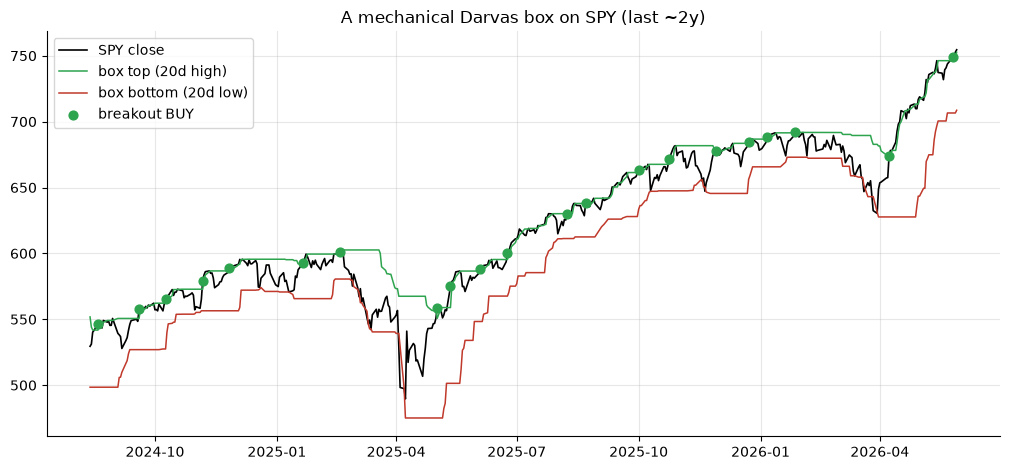

breakouts in window: 21


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    lv = st.box_levels(b, lookback=R['lookback'])
    ent = st.breakout_entries(b, lookback=R['lookback'], min_box=R['min_box'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, lv['box_top'].reindex(seg.index), c=GREEN, lw=1.1, label='box top (20d high)')
    ax.plot(seg.index, lv['box_bottom'].reindex(seg.index), c=RED, lw=1.1, label='box bottom (20d low)')
    ax.scatter(ent, b['close'].reindex(ent), c=GREEN, s=40, zorder=5, label='breakout BUY')
    ax.set_title('A mechanical Darvas box on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('breakouts in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The box tracks the consolidation nicely — *as a description*. The question is whether those green buy dots are followed by continuation. **Let's race the breakout against random entries** at four horizons. Blue = buy the breakout; grey = buy on random days.

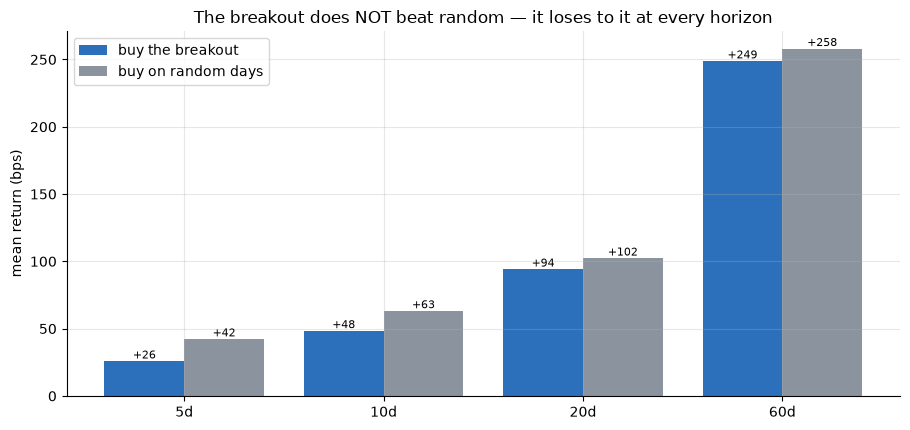

breakout: [26, 48, 94, 249]
random: [42, 63, 102, 258]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    brk, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.breakout_entries(bb, lookback=R['lookback'], min_box=R['min_box'])
            re = st.random_entries(c, max(len(e),50), lookback=R['lookback'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        brk.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='buy the breakout')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The breakout does NOT beat random — it loses to it at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('breakout:', [round(v) for v in brk]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The breakout makes money in absolute terms (**+94 bps** over 20 days) — but **random entries make more** (**+102 bps**). At *every* horizon the famous breakout is *worse* than throwing darts. The apparent edge was **the market's upward drift**, not the box.

**One more sanity check.** What if we keep the same number of trades but **scatter the entry dates at random** — destroying the box-top timing while keeping everything else? If the breakout really forecasts, the random dates should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')
    pl = st.shuffled_box_placebo(c, 20, lookback=R['lookback'], min_box=R['min_box'], n_draws=300, seed=480)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real box breakout (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *random-date* entries do at least as well (p={pval:.2f}).')
print('=> the box-top timing is not doing the work.')

real box breakout (SPY, 20d): +119.8 bps
... but 19% of *random-date* entries do at least as well (p=0.19).
=> the box-top timing is not doing the work.


Around a fifth of the **random-date** runs match or beat the real breakout (*p* = 0.19). If the box top genuinely forecast, random timing would collapse the result. It doesn't — because the result was never about the box.

## 5 · The verdict

- **Signal — None.** The breakout buy does **not** beat buying on random days (it's *worse* at all four horizons; the breakout-vs-random difference is never positive). The big absolute returns are the market's drift, not the box.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Does the box breakout forecast"? — Busted.** Scatter the entry dates and the result barely moves. The box doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade. The breakout's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The Darvas breakout is a worse, more expensive way to be long. Costs (commissions + spread on every breakout) push the already-no-edge result further negative. As a forecasting tool, it doesn't pay; as a trade-management frame, it was never meant to be a standalone strategy on a diversified index.

## 7 · Going further 🚪

- **Single stocks vs indices.** Darvas traded individual high-flyers, not the S&P. A fun follow-up runs the same rule on a survivorship-corrected single-name universe — but beware: that's exactly where survivorship + selection inflate the apparent edge.
- **Channel cousins.** The box is a Donchian/turtle breakout in disguise; see the desk's [Donchian](../../437-donchian-breakout) and [Turtle](../../103-turtle-trader) studies — same drift confound.
- **A real positive control.** The quants notebook plants a *genuine* post-breakout continuation into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the box forecasts? Show the breakout beating random entries at **t ≥ 2** on a real tape — then we'll talk.*